<a href="https://colab.research.google.com/github/sjkim0520/Control_System/blob/main/Koopman_Operator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Data-Driven Koopman Operator Modeling
#  Part A. DMD (Dynamic Mode Decomposition) - 선형 시스템 + 제어입력
#          슬라이드 예제(x_{k+1} = [[1.5,0],[0,0.1]]x_k + [1;0]u_k)를
#          Step1~5 그대로 재현하여 A, B 행렬을 데이터만으로 복원 검증

#  Part B. EDMD (Extended DMD) - 비선형 시스템 + 관측함수(Koopman coordinates)
#          x1dot = a*x1, x2dot = b*(x2 - x1^2) 시스템에서
#          - 선형 관측함수만 쓰면(DMD) 비선형성을 놓침 (한계 시연)
#          - g = [x1, x2, x1^2] 로 확장하면 선형 시스템으로 정확히 표현됨
#            (슬라이드의 해석적 유도: g1dot=a g1, g2dot=b g2 - b g3, g3dot=2a g3)
#          을 데이터로부터 회귀하여 검증

In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [3]:
#Part A. DMD with control imput
def _dmdc_identify(X, Xp, Upsilon, rcond=1e-10):
    """Step 2~5: G = [A B] = X' * pinv([X; Upsilon])  (SVD 기반, rank 부족 안전 처리)"""
    Omega = np.vstack([X, Upsilon])
    U_svd, S, Vt = np.linalg.svd(Omega, full_matrices=False)
    S_inv = np.array([1 / s if s > rcond * S[0] else 0.0 for s in S])
    Omega_pinv = Vt.T @ np.diag(S_inv) @ U_svd.T
    G = Xp @ Omega_pinv
    return G, S


def part_a_dmd_verification():
    print("=" * 70)
    print("Part A. DMD (선형 시스템 + 제어입력) - 슬라이드 예제 재현")
    print("=" * 70)

    # 참값 (검증용) : x_{k+1} = A x_k + B u_k
    A_true = np.array([[1.5, 0.0], [0.0, 0.1]])
    B_true = np.array([[1.0], [0.0]])

    # Step 1. Data collection (슬라이드와 동일한 초기조건/제어입력으로 데이터 생성)
    x = np.array([4.0, 7.0])
    X_cols, Xp_cols, U_cols = [], [], []
    for _ in range(4):
        u = -x[0]  # u_k = -[x1]_k  (슬라이드와 동일한 상태 피드백)
        x_next = A_true @ x + (B_true.flatten()) * u
        X_cols.append(x.copy())
        Xp_cols.append(x_next.copy())
        U_cols.append(u)
        x = x_next

    X = np.array(X_cols).T          # 2x4
    Xp = np.array(Xp_cols).T        # 2x4  (X shifted by one step)
    Upsilon = np.array(U_cols).reshape(1, -1)  # 1x4

    print("\nX  =\n", X)
    print("X' =\n", Xp)
    print("Upsilon =\n", Upsilon)

    G, S = _dmdc_identify(X, Xp, Upsilon)
    A_hat, B_hat = G[:, :2], G[:, 2:]

    print("\n특이값(Sigma):", np.round(S, 4))
    print(">> 세 번째 특이값이 0에 가까움 -> Omega의 rank는 2 (3이 아님)")
    print(">> 원인: u_k = -[x1]_k 는 x1과 완전히 선형종속 (u row == -1 * x1 row)")
    print("   이는 시스템 식별의 필요조건인 'Persistence of Excitation' 위반.")
    print("   -> 이 데이터만으로는 A, B를 '개별적으로' 유일하게 복원할 수 없고,")
    print("      (A의 1열 - B) 조합만 식별 가능함 (SVD pinv는 최소노름 해를 반환).")

    print("\n[SVD 최소노름 해] A_hat =\n", np.round(A_hat, 4))
    print("B_hat =\n", np.round(B_hat, 4))
    combo_hat = A_hat[:, 0] - B_hat.flatten()
    combo_true = A_true[:, 0] - B_true.flatten()
    print(f"\n식별 가능한 조합 (A[:,0]-B): 추정 = {np.round(combo_hat,4)}, "
          f"참값 = {np.round(combo_true,4)}  (이 조합은 정확히 일치해야 함)")

    # ---- 올바른 비교: Persistence of Excitation을 만족하는 입력으로 재식별 ----
    print("\n[비교] u_k를 x1과 무관한 신호(랜덤)로 바꾸면 A, B가 개별적으로 복원됨:")
    rng = np.random.default_rng(0)
    x = np.array([4.0, 7.0])
    X2, X2p, U2 = [], [], []
    for _ in range(20):
        u = rng.uniform(-5, 5)  # x와 무관한 여기(excitation) 신호
        x_next = A_true @ x + (B_true.flatten()) * u
        X2.append(x.copy()); X2p.append(x_next.copy()); U2.append(u)
        x = x_next
    X2, X2p = np.array(X2).T, np.array(X2p).T
    U2 = np.array(U2).reshape(1, -1)

    G2, S2 = _dmdc_identify(X2, X2p, U2)
    A_hat2, B_hat2 = G2[:, :2], G2[:, 2:]
    print("특이값(Sigma):", np.round(S2, 4), "(모두 0과 뚜렷이 떨어짐 -> full rank)")
    print("A_hat =\n", np.round(A_hat2, 4), "\nB_hat =\n", np.round(B_hat2, 4))
    err = np.linalg.norm(np.hstack([A_hat2, B_hat2]) - np.hstack([A_true, B_true]))
    print(f"오차(Frobenius norm): {err:.2e}  -> A, B 정확히 복원됨")

Part A. DMD (선형 시스템 + 제어입력) - 슬라이드 예제 재현

X  =
 [[4.    2.    1.    0.5  ]
 [7.    0.7   0.07  0.007]]
X' =
 [[2.0e+00 1.0e+00 5.0e-01 2.5e-01]
 [7.0e-01 7.0e-02 7.0e-03 7.0e-04]]
Upsilon =
 [[-4.  -2.  -1.  -0.5]]

특이값(Sigma): [9.3715 2.0419 0.    ]
>> 세 번째 특이값이 0에 가까움 -> Omega의 rank는 2 (3이 아님)
>> 원인: u_k = -[x1]_k 는 x1과 완전히 선형종속 (u row == -1 * x1 row)
   이는 시스템 식별의 필요조건인 'Persistence of Excitation' 위반.
   -> 이 데이터만으로는 A, B를 '개별적으로' 유일하게 복원할 수 없고,
      (A의 1열 - B) 조합만 식별 가능함 (SVD pinv는 최소노름 해를 반환).

[SVD 최소노름 해] A_hat =
 [[0.25 0.  ]
 [0.   0.1 ]]
B_hat =
 [[-0.25]
 [ 0.  ]]

식별 가능한 조합 (A[:,0]-B): 추정 = [0.5 0. ], 참값 = [0.5 0. ]  (이 조합은 정확히 일치해야 함)

[비교] u_k를 x1과 무관한 신호(랜덤)로 바꾸면 A, B가 개별적으로 복원됨:
특이값(Sigma): [7.7109441e+03 1.4361800e+01 7.0088000e+00] (모두 0과 뚜렷이 떨어짐 -> full rank)
A_hat =
 [[ 1.5 -0. ]
 [ 0.   0.1]] 
B_hat =
 [[1.]
 [0.]]
오차(Frobenius norm): 4.14e-14  -> A, B 정확히 복원됨

Part B. EDMD (비선형 시스템 + 관측함수 확장)
시스템: x1dot = -0.5*x1,  x2dot = -1.0*(x2 - x1^2)

[B-1] 선형 관측함수만 사용 (g=

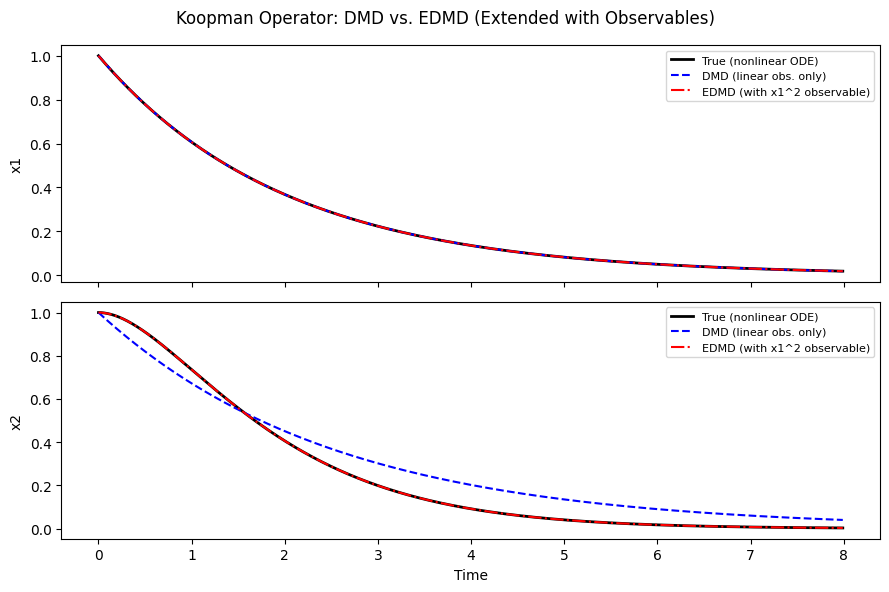


결론: g=[x1,x2]만으로는(DMD) x2의 x1^2 항을 표현할 선형 연산자가 존재하지 않아 궤적이 어긋남.
반면 g=[x1,x2,x1^2]로 관측함수를 확장하면(EDMD) 선형 연산자 K로 '정확히' 표현되며, 시뮬레이션도 True와 일치함.
-> 이것이 슬라이드 24페이지에서 관측함수를 신경망(encoder)으로 자동 학습하려는 동기(Deep Koopman)로 이어짐.


In [6]:
# Part B. EDMD - 비선형 시스템에서 관측함수(Koopman coordinates) 필요성 시연
def nonlinear_system(t, state, a, b):
    x1, x2 = state
    dx1 = a * x1
    dx2 = b * (x2 - x1 ** 2)
    return [dx1, dx2]


def generate_trajectory(a, b, x0, t_end=8, dt=0.01):
    t_eval = np.arange(0, t_end, dt)
    sol = solve_ivp(nonlinear_system, (0, t_end), x0, args=(a, b),
                     t_eval=t_eval, rtol=1e-10, atol=1e-10)
    return t_eval, sol.y.T  # (n_samples, 2) : [x1, x2]


def fit_linear_operator(G, dG):
    """dG/dt = K G  형태의 선형 연산자를 최소자승으로 추정 (연속시간 DMD/EDMD)."""
    K, *_ = np.linalg.lstsq(G, dG, rcond=None)
    return K.T  # dG = G @ K.T  ->  dg_i = K[i,:] . g


def part_b_edmd(a=-0.5, b=-1.0, x0=(1.0, 1.0)):
    print("\n" + "=" * 70)
    print("Part B. EDMD (비선형 시스템 + 관측함수 확장)")
    print(f"시스템: x1dot = {a}*x1,  x2dot = {b}*(x2 - x1^2)")
    print("=" * 70)

    t, X = generate_trajectory(a, b, x0)
    x1, x2 = X[:, 0], X[:, 1]

    # ---------- B-1. 선형 관측함수만 사용 (DMD, 한계 시연) ----------
    G_lin = np.column_stack([x1, x2])                 # g = [x1, x2]
    dG_lin = np.gradient(G_lin, t, axis=0)
    K_lin = fit_linear_operator(G_lin, dG_lin)
    print("\n[B-1] 선형 관측함수만 사용 (g=[x1,x2]) -> DMD 한계")
    print("추정된 K (선형 근사) =\n", np.round(K_lin, 4))
    print("-> x1^2 항을 표현할 방법이 없어 x2 쪽 동역학을 제대로 못 맞춤")

    # ---------- B-2. 확장 관측함수 사용 (EDMD, 슬라이드 예제와 동일) ----------
    g3 = x1 ** 2
    G_ext = np.column_stack([x1, x2, g3])              # g = [x1, x2, x1^2]
    dG_ext = np.gradient(G_ext, t, axis=0)
    K_ext = fit_linear_operator(G_ext, dG_ext)

    K_analytic = np.array([
        [a,   0.0,  0.0],
        [0.0, b,   -b],
        [0.0, 0.0,  2 * a],
    ])

    print("\n[B-2] 확장 관측함수 사용 (g=[x1, x2, x1^2]) -> EDMD")
    print("추정된 K (Koopman 근사, 데이터 기반) =\n", np.round(K_ext, 4))
    print("해석적으로 유도된 K (슬라이드 Part 1 결과) =\n", K_analytic)
    print(f"오차(Frobenius norm): {np.linalg.norm(K_ext - K_analytic):.2e}")

    # ---------- 검증: 식별된 선형 Koopman 시스템으로 순방향 시뮬레이션 ----------
    def koopman_rhs(t, g, K):
        return K @ g

    g0_ext = np.array([x0[0], x0[1], x0[0] ** 2])
    sol_ext = solve_ivp(koopman_rhs, (t[0], t[-1]), g0_ext, args=(K_ext,),
                         t_eval=t, rtol=1e-10, atol=1e-10)

    g0_lin = np.array([x0[0], x0[1]])
    sol_lin = solve_ivp(koopman_rhs, (t[0], t[-1]), g0_lin, args=(K_lin,),
                         t_eval=t, rtol=1e-10, atol=1e-10)
    fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
    axes[0].plot(t, x1, "k-", lw=2, label="True (nonlinear ODE)")
    axes[0].plot(t, sol_lin.y[0], "b--", lw=1.5, label="DMD (linear obs. only)")
    axes[0].plot(t, sol_ext.y[0], "r-.", lw=1.5, label="EDMD (with x1^2 observable)")
    axes[0].set_ylabel("x1")
    axes[0].legend(fontsize=8)

    axes[1].plot(t, x2, "k-", lw=2, label="True (nonlinear ODE)")
    axes[1].plot(t, sol_lin.y[1], "b--", lw=1.5, label="DMD (linear obs. only)")
    axes[1].plot(t, sol_ext.y[1], "r-.", lw=1.5, label="EDMD (with x1^2 observable)")
    axes[1].set_ylabel("x2")
    axes[1].set_xlabel("Time")
    axes[1].legend(fontsize=8)

    fig.suptitle("Koopman Operator: DMD vs. EDMD (Extended with Observables)")
    plt.tight_layout()
    plt.show()
    print(
        "\n결론: g=[x1,x2]만으로는(DMD) x2의 x1^2 항을 표현할 선형 연산자가 "
        "존재하지 않아 궤적이 어긋남.\n"
        "반면 g=[x1,x2,x1^2]로 관측함수를 확장하면(EDMD) 선형 연산자 K로 "
        "'정확히' 표현되며, 시뮬레이션도 True와 일치함.\n"
        "-> 이것이 슬라이드 24페이지에서 관측함수를 신경망(encoder)으로 "
        "자동 학습하려는 동기(Deep Koopman)로 이어짐."
    )


if __name__ == "__main__":
    part_a_dmd_verification()
    part_b_edmd(a=-0.5, b=-1.0, x0=(1.0, 1.0))